In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel('Obesity_Data_clean_onehot.xlsx') 
print('Dataset shape:', df.shape)
df.head()
df.info()

Dataset shape: (2076, 15)
<class 'pandas.DataFrame'>
RangeIndex: 2076 entries, 0 to 2075
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             2076 non-null   int64  
 1   age                2076 non-null   int64  
 2   height             2076 non-null   float64
 3   weight             2076 non-null   float64
 4   family_history     2076 non-null   int64  
 5   high_cal_food      2076 non-null   int64  
 6   snacking           2076 non-null   int64  
 7   smoking            2076 non-null   int64  
 8   physical_activity  2076 non-null   int64  
 9   screen_time        2076 non-null   int64  
 10  alcohol            2076 non-null   int64  
 11  obesity_level      2076 non-null   str    
 12  transport_1        2076 non-null   bool   
 13  transport_2        2076 non-null   bool   
 14  transport_3        2076 non-null   bool   
dtypes: bool(3), float64(2), int64(9), str(1)
memory usage: 20

obesity_level
Insufficient_Weight    267
Normal_Weight          276
Overweight_Level_I     275
Overweight_Level_II    289
Obesity_Type_I         348
Obesity_Type_II        297
Obesity_Type_III       324
Name: count, dtype: int64


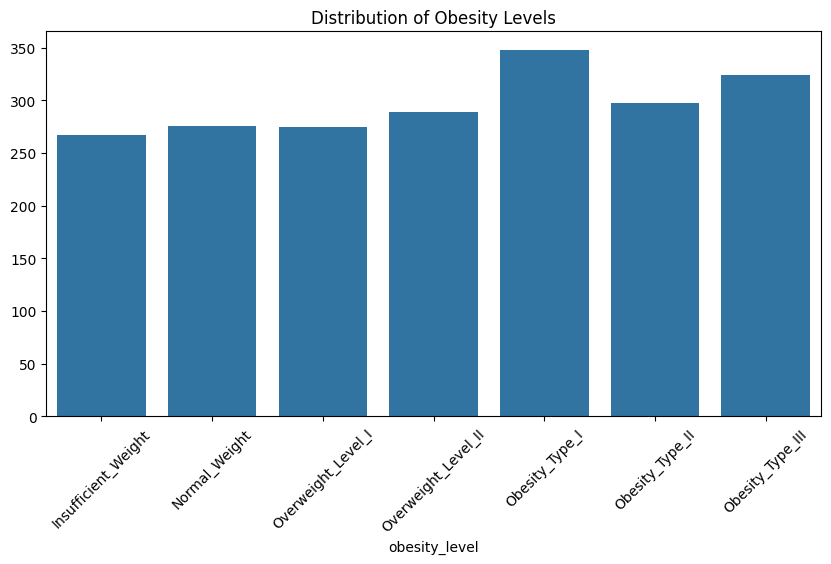

In [34]:
# 1. 定义肥胖程度顺序（从最瘦到最胖）
severity_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]
#将字符串类型转换成有序分类
df['obesity_level'] = pd.Categorical(df['obesity_level'], categories=severity_order, ordered=True)

counts = df['obesity_level'].value_counts (sort=False)#不按数量排序
print(counts)
plt.figure(figsize=(10,5))
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=45)
plt.title('Distribution of Obesity Levels')
plt.show()

In [51]:
from sklearn.model_selection import train_test_split
X = df.drop('obesity_level', axis=1)
y = df['obesity_level']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2, stratify=y
)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Features shape: (2076, 14)
Target shape: (2076,)
Training set size: (1660, 14)
Test set size: (416, 14)


In [52]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['age', 'height', 'weight', 'physical_activity', 'screen_time']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [53]:
import warnings
warnings.filterwarnings('ignore')#忽略警告信息
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score

from sklearn.model_selection import GridSearchCV #交叉验证寻找最佳超参数
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg']
}

lrmodel = LogisticRegression(max_iter=2000, random_state=2)
grid_lrmodel = GridSearchCV(lrmodel, param_grid, cv=5, scoring='f1_macro')
grid_lrmodel.fit(X_train, y_train)
best_lrmodel = grid_lrmodel.best_estimator_
y_pred_model = best_lrmodel.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_model)
f1_macro_test = f1_score(y_test, y_pred_model, average='macro')
f1_score = f1_score(y_test, y_pred_model, average='weighted')

print('Best params:', grid_lrmodel.best_params_)
print('Best CV macro F1:', float(grid_lrmodel.best_score_))
print("Logistic Regression Accuracy:", accuracy)
print(f"Logistic Regression F1-score (weighted): {f1_score:.4f}")
print(f"Logistic Regression F1-score (macro): {f1_macro_test:.4f}")


Logistic Regression Accuracy: 0.9663461538461539
Logistic Regression F1-score (weighted): 0.9662


In [54]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
dt=DecisionTreeClassifier(class_weight='balanced', random_state=2)
param_grid = {
    'max_depth': [12, 15, 18, 20, None],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3, 4]
}
grid_dt = GridSearchCV(dt, param_grid, cv=5, scoring='f1_weighted')
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_dt)
f1_macro_test = f1_score(y_test, y_pred_dt, average='macro')
f1_score = f1_score(y_test, y_pred_dt, average='weighted')
print('Best params:', grid_dt.best_params_)
print('Best CV weighted F1:', float(grid_dt.best_score_))
print("Decision Tree Accuracy:", accuracy)
print(f"Decision Tree F1-score (weighted): {f1_score:.4f}")
print(f"Decision Tree F1-score (macro): {f1_macro_test:.4f}")

Decision Tree Accuracy: 0.9519230769230769
Decision Tree F1-score (weighted): 0.9518


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
}
rf = RandomForestClassifier(random_state=2)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1_weighted', n_jobs=1)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1_macro_test = f1_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='weighted')
print('Best params:', grid.best_params_)
print('Best CV weighted F1:', float(grid.best_score_))
print(f"Random Forest Accuracy: {acc:.4f}")
print(f"Random Forest F1-score (weighted): {f1:.4f}")
print(f"Random Forest F1-score (macro): {f1_macro_test:.4f}")

Random Forest Accuracy: 0.9303
Random Forest F1-score (weighted): 0.9306


In [56]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# XGBoost 需要 0..K-1 整数标签；GridSearchCV 必须在编码后的 y 上拟合
y_train = y_train.cat.codes
y_test = y_test.cat.codes

# 简单网格：较深树、学习率与树数量，便于对比「更复杂是否更差」
param_grid = {
    'max_depth': [4, 10],
    'learning_rate': [0.05, 0.2],
    'n_estimators': [100, 200],
}
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=1,
)
grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=1,
)
grid_search.fit(X_train, y_train)
xgb = grid_search.best_estimator_
print('Best params:', grid_search.best_params_)
print('Best CV macro F1:', float(grid_search.best_score_))

y_pred_xgb = xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_xgb)
f1_macro_test = f1_score(y_test, y_pred_xgb, average='macro')
f1_score = f1_score(y_test, y_pred_xgb, average='weighted')
print("XGBoost Accuracy:", accuracy)
print(f"XGBoost F1-score (weighted): {f1_score:.4f}")
print(f"XGBoost F1-score (macro): {f1_macro_test:.4f}")


Best params: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}
Best CV macro F1: 0.9513882443232092
XGBoost Accuracy: 0.9711538461538461
XGBoost F1-score (weighted): 0.9712


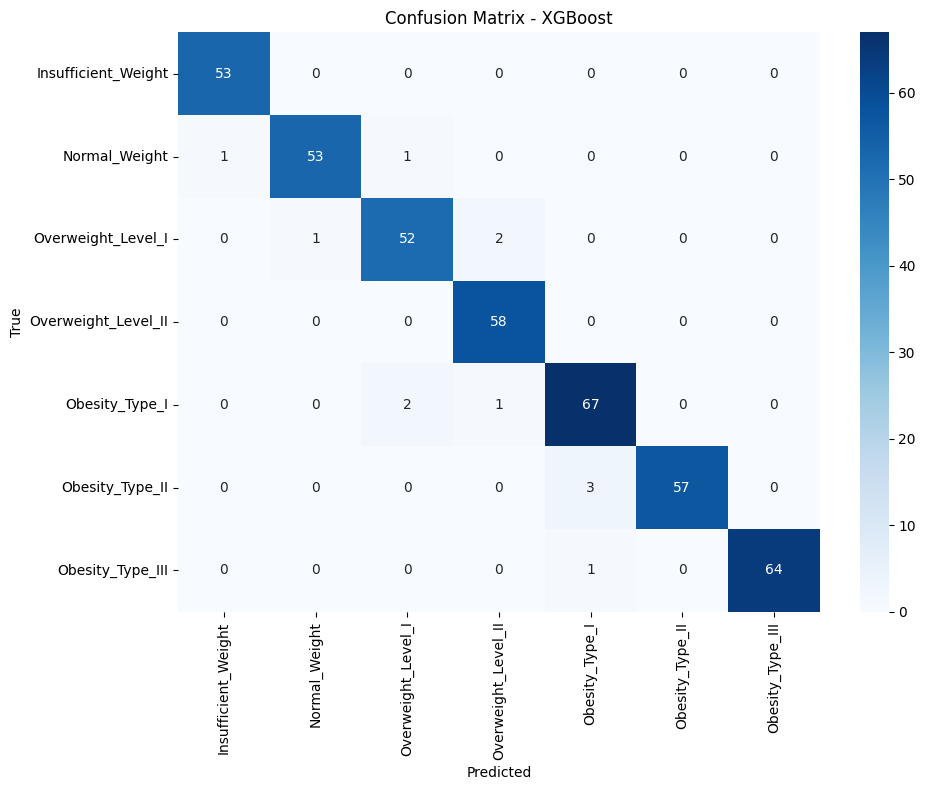


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       0.98      0.96      0.97        55
 Overweight_Level_I       0.95      0.95      0.95        55
Overweight_Level_II       0.95      1.00      0.97        58
     Obesity_Type_I       0.94      0.96      0.95        70
    Obesity_Type_II       1.00      0.95      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65

           accuracy                           0.97       416
          macro avg       0.97      0.97      0.97       416
       weighted avg       0.97      0.97      0.97       416



In [57]:
cm = confusion_matrix(y_test, y_pred_xgb) 
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=severity_order, yticklabels=severity_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - XGBoost')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=severity_order))

Top 10 important features:
gender               0.456611
weight               0.184217
high_cal_food        0.066775
transport_1          0.055114
height               0.053353
alcohol              0.043988
snacking             0.035250
family_history       0.026908
age                  0.021116
physical_activity    0.017872
dtype: float32


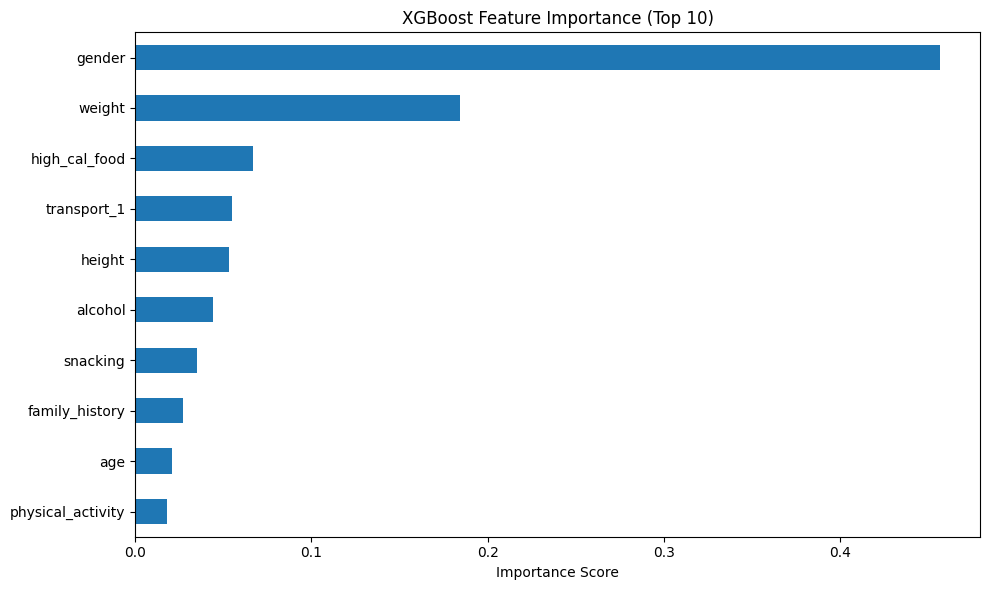

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# 获取特征重要性（默认类型：'weight'，即特征被用作分裂的次数）
importance = xgb.feature_importances_

# 创建 Series，索引为特征名
feat_imp = pd.Series(importance, index=X_train.columns)

# 按重要性降序排列
feat_imp_sorted = feat_imp.sort_values(ascending=False)

# 显示前10个最重要的特征
print("Top 10 important features:")
print(feat_imp_sorted.head(10))
plt.figure(figsize=(10, 6))
feat_imp_sorted.head(10).plot(kind='barh')
plt.gca().invert_yaxis()   # 让最重要的显示在最上面
plt.title('XGBoost Feature Importance (Top 10)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_xgboost.png', dpi=300)
plt.show()